# Title: A hand gesture recognition algorithm based on DC-CNN (Xiao Yan Wu)
Hand gesture recognition is an important area of computer vision and human–computer interaction. It enables computers to understand human intentions through visual hand movements, which can be used in applications such as virtual reality, robotics, smart interfaces, and assistive technologies.

Traditional gesture recognition methods rely heavily on manually designed features such as edges, contours, or geometric descriptors. These handcrafted approaches often struggle with complex backgrounds, lighting variation, and different hand shapes.

Deep learning, especially Convolutional Neural Networks (CNNs), solves this problem by automatically learning visual features directly from images through hierarchical feature extraction. The paper uses Double Channel CNN which is a deep learning architecture where two parallel CNN networks process different representations of the same image (original image and edge image). Features extracted from both channels are fused in a fully connected layer and classified using Softmax, resulting in improved hand gesture recognition accuracy and stronger feature learning. Dataset used is the JTD hand gesture dataset.

In [ ]:
!pip install opencv-python tensorflow scikit-learn matplotlib

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/DC_CNN_Project

/content/drive/MyDrive/DC_CNN_Project


In [ ]:
%cd /content/drive/MyDrive/DC_CNN_Project/Triesch

/content/drive/MyDrive/DC_CNN_Project/Triesch


In [ ]:
!ls | head

a
b
c
d
g
h
i
l
README
v


In [ ]:
!ls b | head

bfritza1.pgm
bfritza2.pgm
bfritza3.pgm
bfritzb1.pgm
bfritzb2.pgm
bfritzb3.pgm
bfritzc1.pgm
bfritzc2.pgm
bfritzc3.pgm
bfritzd1.pgm


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [ ]:
DATASET_PATH = "/content/drive/MyDrive/DC_CNN_Project/Triesch"
classes = ['a','b','c','d','g','h','i','l','v','y']
IMG_SIZE = 32

In [ ]:
# edge detection

def edge_detect(img):
    blur = cv2.GaussianBlur(img,(3,3),0)
    edge = cv2.Canny(blur,50,150)
    return edge

In [ ]:

X_img = []
X_edge = []
y = []
persons = []

for idx, cls in enumerate(classes):

    folder = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(folder):

        if not file.endswith(".pgm"):
            continue

        path = os.path.join(folder, file)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        edge = edge_detect(img)

        img = img.astype(np.float32)/255.0
        edge = edge.astype(np.float32)/255.0

        # -------- PERSON NAME --------
        # remove class letter + number
        person = file[:-5]

        X_img.append(np.expand_dims(img,-1))
        X_edge.append(np.expand_dims(edge,-1))
        y.append(idx)
        persons.append(person)

X_img = np.array(X_img)
X_edge = np.array(X_edge)
y = np.array(y)
persons = np.array(persons)

In [ ]:
y_cat = to_categorical(y, len(classes))

X_img_train, X_img_test, X_edge_train, X_edge_test, y_train, y_test = train_test_split(
    X_img, X_edge, y_cat,
    test_size=0.2,
    random_state=42
)


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15
)


In [ ]:
#cnn branch
def build_branch(input_shape):

    inp = Input(shape=input_shape)

    x = Conv2D(16,(5,5),activation='relu',padding='same')(inp)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(32,(5,5),activation='relu',padding='same')(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    return inp,x





In [ ]:
# DC-CNN
img_input,img_branch = build_branch((IMG_SIZE,IMG_SIZE,1))
edge_input,edge_branch = build_branch((IMG_SIZE,IMG_SIZE,1))

merged = concatenate([img_branch,edge_branch])

fc = Dense(64,activation='relu')(merged)
fc = Dropout(0.4)(fc)

output = Dense(len(classes),activation='softmax')(fc)

model = Model(inputs=[img_input,edge_input], outputs=output)


In [ ]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=loss_fn,
    metrics=['accuracy']
)



In [ ]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)


In [ ]:
history = model.fit(
    [X_img_train, X_edge_train],
    y_train,
    validation_data=([X_img_test, X_edge_test], y_test),
    epochs=30,
    batch_size=32,
    callbacks=[lr_scheduler]
)




Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.1581 - loss: 2.3009 - val_accuracy: 0.1111 - val_loss: 2.2497 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.2003 - loss: 2.2161 - val_accuracy: 0.2083 - val_loss: 2.1198 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.2394 - loss: 2.1040 - val_accuracy: 0.3542 - val_loss: 1.9577 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.3289 - loss: 1.9643 - val_accuracy: 0.4514 - val_loss: 1.8510 - learning_rate: 0.0010
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.4052 - loss: 1.8389 - val_accuracy: 0.4167 - val_loss: 1.8008 - learning_rate: 0.0010
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.5167 - loss: 1.6941 - val_accuracy: 0.5208 - val_loss: 1.6709 - learning_rate: 0.0010
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.4900 - loss: 1.6662 - val

In [ ]:
loss, acc = model.evaluate(
    [X_img_test, X_edge_test],
    y_test
)

print("Test Accuracy:", acc)



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6259 - loss: 1.5095
Test Accuracy: 0.6458333134651184


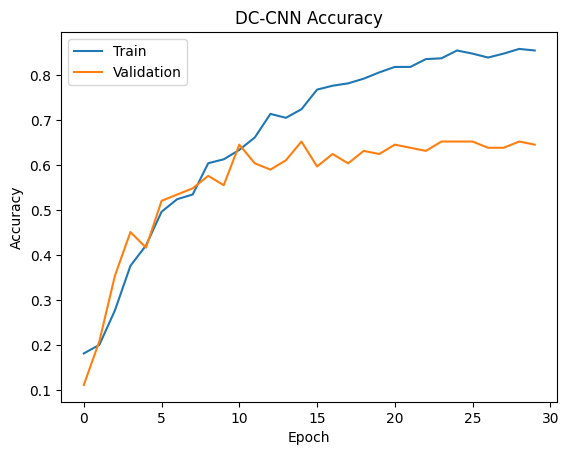

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("DC-CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()
